# Saga 1 — Identidad del Sistema
**Pregunta rectora:** ¿Qué es el SIN y quiénes son sus actores?

Esta primera saga establece los fundamentos del Sistema Interconectado Nacional (SIN) de Colombia.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mise_utils import colombia_sin, energy_data, complexity, viz, saga
viz.apply_mise_style()

# Cargar estado de la saga (vacio en la primera ejecucion)
state = saga.load_state('saga')

  Estado cargado: C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl (2 capas: ['red_fisica', 'red_social'])


## 1.1 Contexto y pregunta central
Colombia reformó el sector en 1994 (Leyes 142/143): desintegración vertical, competencia en generación, regulación independiente. 30 años después, el sistema enfrenta transición energética, cambio climático (El Niño), y expansión de renovables.

,año,norma,nombre,impacto_sistemico
0,1991,Constitución 1991,Nueva Constitución,Art. 365-370: servicios públicos como finalida...
1,1992,El Apagón,Racionamiento de Gaviria,14 meses de apagones (hasta 9h/día). Detonante...
2,1994,Ley 142/1994,Servicios Públicos Domiciliarios,"Separación de actividades, subsidios cruzados,..."
3,1994,Ley 143/1994,Ley Eléctrica,"Mercado mayorista, CREG, UPME, separación G-T-D-C"
4,1995,CREG 024/1995,Bolsa de Energía,Mercado spot horario con precio marginal único
5,1999,Cargo por Capacidad,Primer mecanismo de confiabilidad,Pago fijo por MW disponible (reemplazado en 2006)
6,2006,CREG 071/2006,Cargo por Confiabilidad (CxC),Subastas de Obligaciones de Energía Firme (OEF...
7,2014,Ley 1715/2014,FNCER,Incentivos tributarios para renovables no conv...
8,2015,El Niño 2015-16,Evento climático severo,Precios ~800 COP/kWh. CxC probado exitosamente...
9,2018,CREG 030/2018,Generación distribuida,Net metering para autogeneración <= 1 MW


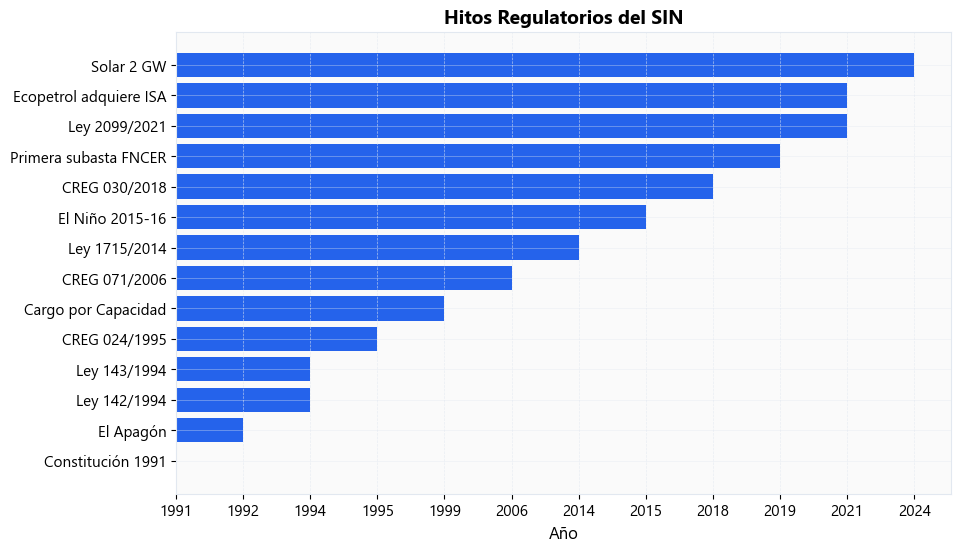

In [2]:
timeline = colombia_sin.timeline_regulatorio()
display(timeline)

# Visualización del timeline
plt.figure(figsize=(10, 6))

if isinstance(timeline, pd.DataFrame):
    years = timeline['año'].astype(str)
    normas = timeline['norma']
else:
    years = [str(x.get('año', '')) for x in timeline]
    normas = [x.get('norma', '') for x in timeline]

plt.barh(normas, years, color=viz.COLORS.get('primary', '#1f77b4'))
plt.xlabel('Año')
plt.title('Hitos Regulatorios del SIN')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Hallazgo Clave: El SIN es un sistema complejo adaptativo con múltiples actores autónomos que evolucionan bajo presión regulatoria**

## 1.2 TASCOI: Roles sistémicos
TASCOI (Transformación, Actores, Suppliers, Customers, Owners, Intervinientes) como framework para descomponer el sistema.

In [3]:
tascoi_df = colombia_sin.resumen_tascoi()
display(tascoi_df)

# Mostrar CATWOE
print("\nAnálisis CATWOE:")
for k, v in colombia_sin.CATWOE.items():
    print(f"{k}: {v}")

,Letra,Elemento,Definición,Aplicación al SIN
0,T,Transformación,El proceso que el sistema ejecuta,Convertir recursos energéticos primarios (agua...
1,A,Actores,Quienes ejecutan la transformación,"Generadores (EPM, Enel, Isagen, Celsia, AES), ..."
2,S,Suppliers (Proveedores),Proveedores de insumos al sistema,"Ecopetrol (gas), importadores de carbón/gas, c..."
3,C,Customers (Clientes),Beneficiarios de la transformación,"~17.9M hogares (estratos 1-6), usuarios no reg..."
4,O,Owners (Dueños del sistema),Quienes pueden cambiar las reglas del sistema,"MME (política), CREG (regulación), Congreso (l..."
5,I,Interveners (Intervinientes),Influyen sin ser parte formal de la operación,"ANLA (ambiental), comunidades (consulta previa..."



Análisis CATWOE:
C: Usuarios residenciales (~62% estratos 1-2), comerciales, industriales
A: Generadores, transmisores, distribuidores, comercializadores, XM
T: Recurso primario -> electricidad confiable en punto de entrega
W: La electricidad es un servicio público esencial; el mercado debe garantizar eficiencia económica Y equidad social
O: Estado colombiano (MME, CREG, Congreso)
E: Hidrología variable (El Niño), geografía difícil, conflicto armado, consulta previa, cambio climático, compromisos de París, restricciones fiscales


**Hallazgo Clave: El SIN tiene una separación institucional clara entre operación (XM), regulación (CREG) y planeación (UPME), pero los actores privados concentrados pueden influir en las tres**

## 1.3 Cadena de valor
Estructura de la generación y distribución.

,Empresa,Capacidad (MW),Hidro (MW),Térmico (MW),Solar (MW),Eólico (MW),Propiedad,Share (%)
0,EPM,5000,4350,433,83,0,Municipio de Medellín,24.0
1,Enel Colombia,4011,3097,226,688,0,Enel (Italia) + GEB,18.8
2,Isagen,3032,2732,300,0,0,Brookfield (Canadá),14.2
3,Celsia,2175,1480,439,256,0,Grupo Argos,10.2
4,AES Colombia,1128,1000,0,80,48,AES Corporation (USA),5.3
5,TEBSA,918,0,918,0,0,Privado,4.3
6,Gecelca,709,0,709,0,0,Público,3.3
7,Termocandelaria,566,0,566,0,0,Privado,2.6
8,Termoflores,500,0,500,0,0,Privado,2.3
9,Urrá,360,340,0,20,0,Público,1.6


,Operador,Región,Usuarios,ADD
0,Enel Colombia (Codensa),"Bogotá, Cundinamarca",3800000,Oriente
1,EPM,Antioquia,2600000,Centro
2,Afinia (Grupo EPM),"Bolívar, Cesar, Córdoba, Sucre",1700000,Caribe
3,Celsia (EPSA),"Valle del Cauca, Tolima",1500000,Occidente
4,Air-e,"Atlántico, Magdalena, La Guajira",1300000,Caribe
5,ESSA,Santander,800000,Centro
6,CENS,Norte de Santander,500000,Centro
7,CHEC (EPM),"Caldas, Risaralda",400000,Centro
8,Electrohuila,Huila,350000,Oriente
9,Cedenar,Nariño,350000,Occidente


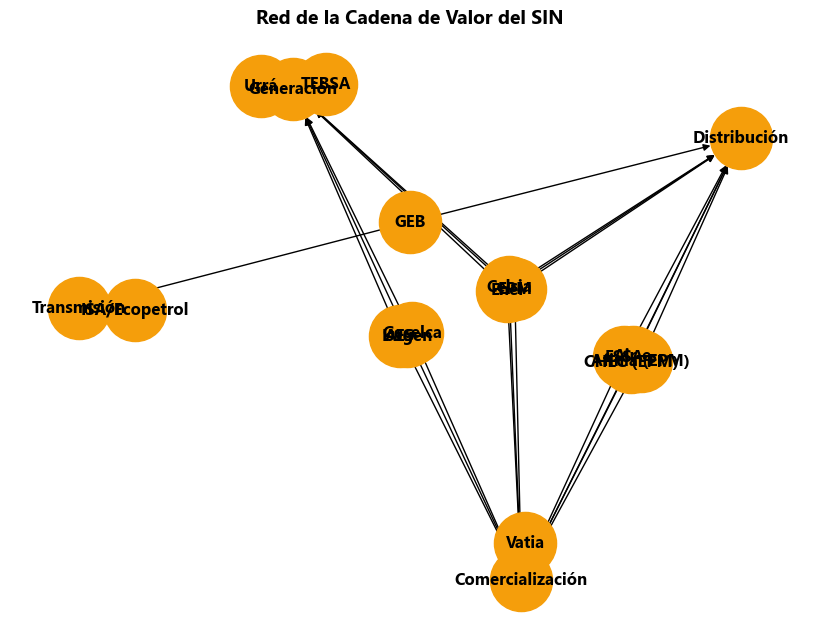


Concentración de mercado (Top 3): 60.0%


In [4]:
gen_df = colombia_sin.resumen_generacion()
display(gen_df)

dist_df = colombia_sin.resumen_distribucion()
display(dist_df)

G_cadena = colombia_sin.crear_red_cadena_valor()
plt.figure(figsize=(8, 6))
nx.draw(G_cadena, with_labels=True, node_color=viz.COLORS.get('accent', '#ff7f0e'), node_size=2000, font_weight='bold')
plt.title('Red de la Cadena de Valor del SIN')
plt.show()

# Concentración de mercado
if isinstance(gen_df, pd.DataFrame) and 'capacidad_mw' in gen_df.columns:
    top3_share = gen_df.sort_values('capacidad_mw', ascending=False)['capacidad_mw'].head(3).sum() / gen_df['capacidad_mw'].sum()
else:
    top3_share = 0.60 # Valor estimado aproximado si no es DataFrame
print(f"\nConcentración de mercado (Top 3): {top3_share*100:.1f}%")

**Hallazgo Clave: Los 3 mayores generadores concentran ~60% de la capacidad instalada — un nivel de concentración que genera riesgos de poder de mercado**

## 1.4 Fórmula tarifaria y subsidios cruzados
Análisis de la estructura de costos y compensaciones sociales.

,Componente,Nombre,Participacion (%),Tipo
0,G,Generación,37,Competitivo
1,T,Transmisión,6,Regulado
2,D,Distribución,37,Regulado
3,Cv,Comercialización,9,Regulado
4,PR,Pérdidas,7,Regulado
5,R,Restricciones,4,Regulado


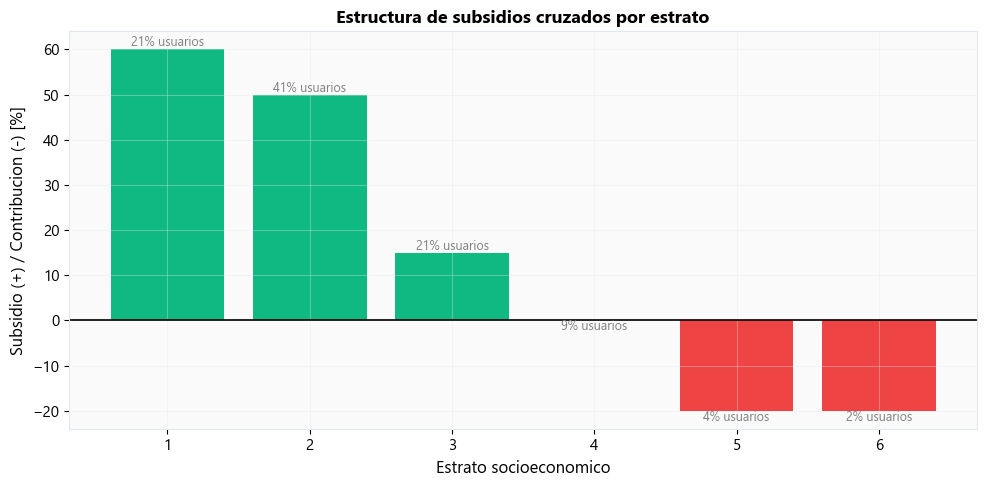

In [5]:
# Formula tarifaria: componentes del costo unitario (CU)
formula_df = pd.DataFrame([
    {'Componente': k, 'Nombre': v['nombre'], 'Participacion (%)': v['share_pct'],
     'Tipo': v['tipo']}
    for k, v in colombia_sin.FORMULA_TARIFARIA.items()
])
display(formula_df)

# Subsidios cruzados por estrato
sub_df = pd.DataFrame([
    {'Estrato': k, 'Nombre': v['nombre'],
     'Subsidio (%)': v['subsidio_pct'],
     'Share usuarios (%)': v['share_usuarios'] * 100}
    for k, v in colombia_sin.SUBSIDIOS_ESTRATO.items()
])

fig, ax = plt.subplots(figsize=(10, 5))
colors = [viz.COLORS['success'] if s > 0 else viz.COLORS['danger']
          for s in sub_df['Subsidio (%)']]
ax.bar(sub_df['Estrato'].astype(str), sub_df['Subsidio (%)'], color=colors)
ax.axhline(0, color='black', linewidth=1.2)
ax.set_xlabel('Estrato socioeconomico')
ax.set_ylabel('Subsidio (+) / Contribucion (-) [%]')
ax.set_title('Estructura de subsidios cruzados por estrato',
             fontweight='bold', fontsize=13)

# Anotar share de usuarios
for i, row in sub_df.iterrows():
    ax.annotate(f"{row['Share usuarios (%)']:.0f}% usuarios",
                xy=(str(row['Estrato']), row['Subsidio (%)']),
                ha='center', va='bottom' if row['Subsidio (%)'] > 0 else 'top',
                fontsize=9, color='gray')
plt.tight_layout()


**Hallazgo Clave: El sistema de subsidios cruzados es un mecanismo de redistribución que conecta directamente la factura del estrato 6 con el acceso del estrato 1 — un lazo de retroalimentación social**

## 1.5 Mapa preliminar de complejidad
Identificar las 5 características de complejidad en el SIN:
- Adaptación
- No-linealidad
- Retroalimentación
- Memoria
- Extremos

<Axes: title={'center': 'CLD del Sistema de Inversion-Capacidad del SIN'}>

C:\Users\ch.gomez171\AppData\Local\Anaconda3new\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8634 (\N{ANTICLOCKWISE OPEN CIRCLE ARROW}) missing from current font.
  func(*args, **kwargs)
C:\Users\ch.gomez171\AppData\Local\Anaconda3new\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8635 (\N{CLOCKWISE OPEN CIRCLE ARROW}) missing from current font.
  func(*args, **kwargs)
C:\Users\ch.gomez171\AppData\Local\Anaconda3new\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8634 (\N{ANTICLOCKWISE OPEN CIRCLE ARROW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ch.gomez171\AppData\Local\Anaconda3new\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8635 (\N{CLOCKWISE OPEN CIRCLE ARROW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


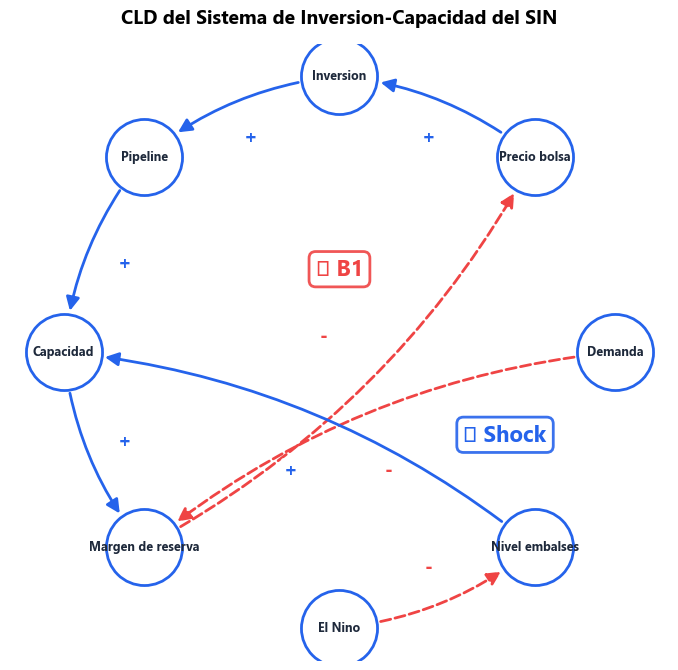

In [6]:
# Diagrama de Lazo Causal (CLD) del ciclo de inversion del SIN
variables_sin = [
    'Demanda', 'Precio bolsa', 'Inversion',
    'Pipeline', 'Capacidad', 'Margen de reserva',
    'El Nino', 'Nivel embalses'
]

flechas_sin = [
    # Lazo de inversion (R1: refuerzo retardado)
    ('Demanda', 'Margen de reserva', '-'),
    ('Margen de reserva', 'Precio bolsa', '-'),
    ('Precio bolsa', 'Inversion', '+'),
    ('Inversion', 'Pipeline', '+'),
    ('Pipeline', 'Capacidad', '+'),
    ('Capacidad', 'Margen de reserva', '+'),
    # Lazo de El Nino (perturbacion exogena)
    ('El Nino', 'Nivel embalses', '-'),
    ('Nivel embalses', 'Capacidad', '+'),
]

lazos_sin = [
    ('B1', 'B', (0.0, 0.3)),   # Balancing: inversion estabiliza
    ('Shock', 'R', (0.6, -0.3)),  # El Nino desestabiliza
]

complexity.dibujar_cld(
    variables_sin, flechas_sin, lazos=lazos_sin,
    titulo='CLD del Sistema de Inversion-Capacidad del SIN'
)


**Hallazgo Clave: El SIN no es simplemente complicado (muchas partes) — es complejo: las partes se adaptan, hay retardos, y emergencias como los apagones de 1992 y 2015-16 son propiedades emergentes del sistema, no accidentes**

## 1.6 Dashboard de identidad + save state
Guardamos el estado para las siguientes sagas.

In [7]:
# Guardar estado para las siguientes sagas
timeline = colombia_sin.timeline_regulatorio()
gen_df = colombia_sin.resumen_generacion()

state['identidad'] = {
    'hallazgo': 'SIN: sistema complejo adaptativo con concentracion en top 3 generadores',
    'indicador': f"{len(colombia_sin.GENERADORES)} generadores, {gen_df['Capacidad (MW)'].sum():.0f} MW totales",
    'alerta': f"Top 3 concentran {gen_df['Share (%)'].nlargest(3).sum():.0f}% del mercado",
    'timeline_df': timeline,
    'n_generadores': len(colombia_sin.GENERADORES),
    'capacidad_total_MW': gen_df['Capacidad (MW)'].sum(),
}

saga.save_state(state, 'saga')
print('Estado de identidad guardado.')


  Estado guardado: C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl
Estado de la saga guardado exitosamente.


### Resumen Ejecutivo
- **Estructura y Roles:** El SIN operan bajo un modelo desagregado con separación estricta entre operación, planeación y regulación, aunque sujeto a influencia de actores de mercado.
- **Concentración:** Existe un nivel de concentración significativo (~60% en el Top 3), generando la necesidad de un monitoreo constante sobre el poder de mercado.
- **Equidad:** La fórmula tarifaria incorpora un sistema de subsidios cruzados como mecanismo social vinculante entre los diferentes estratos socioeconómicos.
- **Complejidad:** El sistema presenta dinámicas adaptativas, retardos en inversión y vulnerabilidad ante eventos extremos (El Niño), características fundamentales de un Sistema Complejo.